# Four-corner mean Z4 (OPD) against truss, ambient and camera-body temperature

**Author:** Aaron Roodman (with Claude Code)
**Date created:** 2026-09-09
**Last modified:** 2026-09-09
**Status:** current
**Keywords:** AOS, corner wavefront sensor, Z4, defocus, v-mode 1, truss temperature, ConsDB, EFD

## Description

Tests whether the total Active Optics System (AOS) optical state on ordinary **science**
exposures correlates with Telescope Mount Assembly (TMA) truss temperature, outside ambient
temperature, or camera-body temperature.

The total is assembled as

```
v1_total = v1(hexapod LUT) + v1(Trim) + v1_equivalent(four-corner mean Z4)
```

where LUT is the hexapod look-up table (the elevation- and temperature-dependent baseline)
and Trim is the accumulated closed-loop offset. A physical hexapod position is LUT + Trim; the
third term converts the *measured* wavefront into the equivalent commanded motion, so all
three are in the same dimensionless v-mode-1 units and can be added.

The measured term is the **four-corner mean Z4 (OPD)** — the mean over the four corner
wavefront sensors of the total optical path difference (OPD) Zernike 4 that the Consolidated
Database (ConsDB) stores per CCD. It is deliberately *not* called DZ(1,4): four field points
cannot separate a field-constant defocus from real field tilt, and this is a different
estimator from the 189-detector Double Zernike (DZ) fit used in
`code/correlations/run_dz14_truss.py`. The batoid intrinsic wavefront is not subtracted — it
is small and nearly field-constant, so it displaces the zero point without changing any slope
(Section 5 prints the four per-corner intrinsic Z4 values so the size of that assumption is
visible rather than assumed).

Complements `run_dz14_truss.py`, which asks the same physical question on Full Array Mode
(FAM) exposures with a 189-detector DZ fit. Science exposures carry corner Zernikes for free,
so this is a much larger and differently-selected sample.

## Output

`aos/output/notebooks/correlations/corner_z4_vs_temperature_science*.{parquet,png}`

## References

- `aos/docs/studies/correlations.md` — the study this belongs to
- `aos/docs/telemetry.md` — LUT / Trim / Tweak column mapping and ConsDB coverage
- `olr/docs/zernike_opd_vs_consdb.md` — ConsDB corner Zernikes are total OPD, not deviation
- `olr/docs/vmode_normalization.md` — why the v-modes must come from the OFC config weights

## Change log

| date | change |
|---|---|
| 2026-09-09 | initial version |

## Table of contents

1. [Parameters](#params)
2. [Imports and clients](#imports)
3. [Science visits](#visits)
4. [v-mode machinery and the two routes](#vmodes)
5. [Intrinsic Z4 — how constant is "constant"?](#intrinsic)
6. [Fetch: corner Z4, LUT, Trim, temperatures](#fetch)
7. [Assemble v1_total](#assemble)
8. [Scatter against temperature, by band](#scatter)
9. [Findings](#findings)

<a id="params"></a>
## 1. Parameters

In [1]:
# --- selection ---------------------------------------------------------------
DAY_OBS_MIN = 20260419
DAY_OBS_MAX = 20260713
IMG_TYPE = 'science'
BANDS = ['g', 'r', 'i', 'z']
INSTRUMENT = 'lsstcam'

# --- v-mode construction -----------------------------------------------------
DOF_SET = 'standard_22'      # 10 rigid + M1M3 bending 1-7 + M2 bending 1-5
N_MODES = 12
K_MIN, K_MAX = 1, 6          # focal-Zernike order range, matching the DZ fits

# v-mode 1 per um of hexapod dz, the mean of the camera- and M2-hexapod dz coefficients
# (they agree to 2.1%). Recomputed from the SVD in Section 4 and checked against this.
V1_PER_UM_DZ_EXPECT = 9.0095e-4          # [1/um]
DZ_TO_UM_EXPECT = -1110.03               # [um of hexapod dz per um of wavefront]

# The sign of the measured-wavefront term is not fixed a priori (the OPD sign convention
# relative to the commanded DOF is not established), so both are evaluated and reported.
MEASURED_SIGNS = (+1.0, -1.0)

# --- temperatures (ConsDB efd_lsstcam.exposure_efd, names from aos_consdb_efd.TEMP_COLS) --
TRUSS_COLS = ['tma_truss_temp_pxpy', 'tma_truss_temp_mxmy']   # salindex122 temperature_6,_7
AMBIENT_COL = 'outside_temp'                                  # salindex301 temperature_0_mean
# The camera-body ESS (salindex 1, mapped to cam_hex_temp_0..7) is EMPTY over this whole
# range -- 0 of 27671 science visits carry any of its eight channels -- so the camera
# temperature used here is the camera AIR temperature from the salindex-111 ESS, whose
# channel 0 is the only populated one. Section 6 measures this rather than assuming it.
CAMERA_COL = 'cam_air_temp'                                   # salindex111 temperature_0_mean
CAMBODY_COLS = [f'cam_hex_temp_{i}' for i in range(8)]        # salindex1, checked for coverage

# --- fetch / cache -----------------------------------------------------------
CHUNK = 400                  # visit ids per ConsDB corner-Zernike query
USE_CACHE = True             # reuse the parquet cache if present
BAND_COLORS = {'g': 'tab:green', 'r': 'tab:red', 'i': 'tab:brown', 'z': 'tab:purple'}
FIGSIZE = (15, 4.2)

<a id="imports"></a>
## 2. Imports and clients

The topic-walking bootstrap: a notebook has no `__file__`, so walk up to the directory that
contains `code/` and put the repo root, `aos/code` and its study subdirectories on the path.

In [2]:
import sys
from pathlib import Path

_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))        # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))      # flat cross-study modules
for _d in sorted((_TOPIC / 'code').glob('*/')):
    if _d.is_dir() and not _d.name.startswith(('_', '.')):
        sys.path.insert(0, str(_d))
print('topic  :', _TOPIC)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import QTable
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

from common.utils import nmad
from common.telemetry_clients import make_consdb_client
import aos_state
import aos_trim
import aos_consdb_efd
from lsst.ts.intrinsic.wavefront import ofc_svd as osv

from lsst_efd_client import EfdClient

cdb = make_consdb_client()
efd = EfdClient('usdf_efd', output_mode='dataframe')

OUT = _TOPIC / 'output' / 'notebooks' / 'correlations'
OUT.mkdir(parents=True, exist_ok=True)
CACHE = OUT / f'corner_z4_vs_temperature_science_{DAY_OBS_MIN}_{DAY_OBS_MAX}.parquet'
print('cache  :', CACHE)

topic  : /sdf/home/r/roodman/notebooks/rubin-work/aos


        Use pytest instead. [astropy.tests.runner]
        Use pytest instead.


        Use pytest instead. [astropy.utils.decorators]
        Use pytest instead.


cache  : /sdf/home/r/roodman/notebooks/rubin-work/aos/output/notebooks/correlations/corner_z4_vs_temperature_science_20260419_20260713.parquet


In [3]:
def huber_fit(x, y):
    """Huber M-estimator slope plus Pearson r and Spearman rho on the finite pairs.

    Parameters
    ----------
    x, y : `array_like`
        Paired values, each in its own single unit; the slope carries y-units per x-unit.

    Returns
    -------
    res : `dict` or `None`
        ``n``, ``slope``, ``slope_err``, ``intercept``, ``pearson_r``, ``spearman_rho``,
        ``resid_nmad``. `None` if fewer than 10 finite pairs remain.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 10:
        return None
    x, y = x[m], y[m]
    X = sm.add_constant(x)
    r = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
    return dict(n=int(x.size), intercept=float(r.params[0]), slope=float(r.params[1]),
                slope_err=float(r.bse[1]),
                pearson_r=float(pearsonr(x, y)[0]),
                spearman_rho=float(spearmanr(x, y)[0]),
                resid_nmad=float(nmad(y - r.predict(X))))

<a id="visits"></a>
## 3. Science visits

`img_type = 'science'`, bands g/r/i/z, over the requested `day_obs` range.

In [4]:
bandlist = ', '.join(f"'{b}'" for b in BANDS)
q = (f"SELECT visit_id, day_obs, seq_num, band, exp_midpt_mjd, s_ra, s_dec, "
     f"       altitude, sky_rotation "
     f"FROM cdb_{INSTRUMENT}.visit1 "
     f"WHERE day_obs BETWEEN {DAY_OBS_MIN} AND {DAY_OBS_MAX} "
     f"  AND img_type = '{IMG_TYPE}' AND band IN ({bandlist}) "
     f"ORDER BY day_obs, seq_num")
visits = cdb.query(q).to_pandas()
for c in ('visit_id', 'day_obs', 'seq_num'):
    visits[c] = visits[c].astype(int)
print(f'science visits in g/r/i/z, day_obs {DAY_OBS_MIN}-{DAY_OBS_MAX}: '
      f'n = {len(visits)} over {visits.day_obs.nunique()} nights')
print(visits.groupby('band').agg(n_visits=('visit_id', 'size'),
                                 n_nights=('day_obs', 'nunique')))

science visits in g/r/i/z, day_obs 20260419-20260713: n = 27671 over 52 nights
      n_visits  n_nights
band                    
g         2663        36
i        11063        48
r         5900        45
z         8045        46


<a id="vmodes"></a>
## 4. v-mode machinery and the two routes

Two different projections onto the same Optical Feedback Control (OFC) subspace are needed,
because the two kinds of input travel through it in opposite directions:

- **degree of freedom (DOF) → v-mode**, for the commanded LUT and Trim:
  `aos_state.make_state_estimator` + `aos_state.vmodes_from_dofs`, which wrap the canonical
  `StateEstimator.get_vmodes_from_dofs`.
- **wavefront → v-mode**, for the measured term: the singular-value decomposition (SVD)
  built by `ofc_svd.build_ofc_svd`, whose `U_eff[(1,4),0]` entry gives the µm of equivalent
  hexapod dz per µm of wavefront of field-constant defocus.

Both are existing code and neither is reimplemented here. Degenerate singular-value pairs make
individual v-modes basis-dependent, so all code must share one right-singular basis; v-mode 1
is non-degenerate and therefore unique, which is the only mode used below.

The two routes are cross-checked against each other, and against the five-coefficient shortcut
`V1_HEX` / `V1_BEND` that `run_dz14_truss.py` uses, before any result depends on them.

In [5]:
se = aos_state.make_state_estimator(dof_set=DOF_SET)
DOF22 = aos_state.DOF22
ZK_NOLL = aos_state.ZK_NOLL
print(f'state estimator: dof_set={DOF_SET}, active DOF indices = {DOF22}')
print(f'Zernikes: Z{ZK_NOLL[0]}..Z{ZK_NOLL[-1]} excluding Z20,Z21 -> {len(ZK_NOLL)} terms')

# v-mode 1 coefficient per unit of each active DOF, from the canonical route.
v1_coef = {}
for k in DOF22:
    d = np.zeros(50)
    d[k] = 1.0
    v1_coef[k] = float(aos_state.vmodes_from_dofs(d, se, n_modes=N_MODES)[0, 0])

V1_PER_UM_DZ = 0.5 * (abs(v1_coef[5]) + abs(v1_coef[0]))
print(f'\nv1 per um of camera-hexapod dz (dof5) = {v1_coef[5]:+.7e} per um')
print(f'v1 per um of M2-hexapod dz     (dof0) = {v1_coef[0]:+.7e} per um')
print(f'mean magnitude V1_PER_UM_DZ           = {V1_PER_UM_DZ:.5e} per um '
      f'(expected {V1_PER_UM_DZ_EXPECT:.5e}); the two axes agree to '
      f'{100*abs(v1_coef[5]-v1_coef[0])/V1_PER_UM_DZ:.1f}%')

state estimator: dof_set=standard_22, active DOF indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 30, 31, 32, 33, 34]
Zernikes: Z4..Z26 excluding Z20,Z21 -> 21 terms

v1 per um of camera-hexapod dz (dof5) = -8.9153336e-04 per um
v1 per um of M2-hexapod dz     (dof0) = -9.1035126e-04 per um
mean magnitude V1_PER_UM_DZ           = 9.00942e-04 per um (expected 9.00950e-04); the two axes agree to 2.1%


In [6]:
# wavefront -> v-mode: the field-constant-defocus content of v-mode 1.
svd = osv.build_ofc_svd(ZK_NOLL, K_MIN, K_MAX, N_MODES, n_dof=DOF22)
i14 = [i for i, (k, j) in enumerate(svd.kj_grid) if (k, j) == (1, 4)]
u14 = float(svd.U_eff[i14[0], 0])
DZ_TO_UM = 1.0 / (V1_PER_UM_DZ * u14)
print(f'U_eff[(k=1,j=4), mode 0] = {u14:+.6f} (dimensionless): v-mode 1 is '
      f'{100*u14**2:.2f}% field-constant defocus by power')
print(f'DZ_TO_UM = {DZ_TO_UM:+.2f} um of hexapod dz per um of wavefront of '
      f'field-constant defocus  (expected {DZ_TO_UM_EXPECT:+.2f})')
assert abs(DZ_TO_UM - DZ_TO_UM_EXPECT) < 0.1, 'conversion factor moved -- investigate'
print('\n-> the two routes are consistent: the same V1_PER_UM_DZ that the DOF route gives '
      'for the hexapod dz axes\n   is what converts the measured wavefront into v-mode 1.')

U_eff[(k=1,j=4), mode 0] = -0.999919 (dimensionless): v-mode 1 is 99.98% field-constant defocus by power
DZ_TO_UM = -1110.04 um of hexapod dz per um of wavefront of field-constant defocus  (expected -1110.03)

-> the two routes are consistent: the same V1_PER_UM_DZ that the DOF route gives for the hexapod dz axes
   is what converts the measured wavefront into v-mode 1.


In [7]:
# Cross-check the canonical DOF route against the 5-coefficient shortcut used in
# code/correlations/run_dz14_truss.py, on the same DOF vectors.
V1_HEX = {5: -0.0008915, 0: -0.0009104}
V1_BEND = {12: +0.1172, 34: +0.1142, 33: +0.001562}
short = {**V1_HEX, **V1_BEND}
rows = []
for k in DOF22:
    unit = 'um' if k in (0, 1, 2, 5, 6, 7) else ('arcsec' if k in (3, 4, 8, 9) else 'um')
    rows.append(dict(dof=k, unit=unit, canonical=v1_coef[k], shortcut=short.get(k, 0.0),
                     diff=v1_coef[k] - short.get(k, 0.0)))
coef_tbl = pd.DataFrame(rows)
big = coef_tbl[coef_tbl[['canonical', 'shortcut']].abs().max(axis=1) > 1e-5]
print('v-mode 1 coefficient per unit DOF [dimensionless per um or per arcsec]:')
print(big.to_string(index=False, float_format=lambda v: f'{v:+.7f}'))
missing = coef_tbl[(coef_tbl.shortcut == 0) & (coef_tbl.canonical.abs() > 1e-5)]
print(f'\nThe shortcut keeps {len(short)} coefficients and omits {len(missing)} smaller ones '
      f'(DOF {list(missing.dof)}).')
print('It reproduces the hexapod dz axes exactly, so the two routes agree on the quantity '
      'this notebook\nuses most; on a general 22-DOF vector they differ by ~10% because the '
      'omitted terms multiply\nlarge tilt values. The canonical route is used throughout '
      'below.')

v-mode 1 coefficient per unit DOF [dimensionless per um or per arcsec]:
 dof   unit  canonical   shortcut       diff
   0     um -0.0009104 -0.0009104 +0.0000000
   3 arcsec -0.0003144 +0.0000000 -0.0003144
   4 arcsec +0.0002750 +0.0000000 +0.0002750
   5     um -0.0008915 -0.0008915 -0.0000000
   8 arcsec +0.0000521 +0.0000000 +0.0000521
   9 arcsec -0.0000514 +0.0000000 -0.0000514
  10     um +0.0001212 +0.0000000 +0.0001212
  11     um -0.0006821 +0.0000000 -0.0006821
  12     um +0.1171661 +0.1172000 -0.0000339
  13     um -0.0007832 +0.0000000 -0.0007832
  15     um -0.0001154 +0.0000000 -0.0001154
  16     um +0.0000130 +0.0000000 +0.0000130
  33     um +0.0015616 +0.0015620 -0.0000004
  34     um +0.1141915 +0.1142000 -0.0000085

The shortcut keeps 5 coefficients and omits 9 smaller ones (DOF [3, 4, 8, 9, 10, 11, 13, 15, 16]).
It reproduces the hexapod dz axes exactly, so the two routes agree on the quantity this notebook
uses most; on a general 22-DOF vector they differ by ~10

<a id="intrinsic"></a>
## 5. Intrinsic Z4 — how constant is "constant"?

The ConsDB corner Zernikes are total OPD, so the four-corner mean Z4 contains the telescope's
intrinsic (design) defocus at the corner field positions as well as any real focus error. The
intrinsic is dropped as small and nearly field-constant. That makes the zero point of
`v1_total` arbitrary but leaves every slope against temperature unchanged — provided the
intrinsic really is constant across the four corners. The four per-corner values are printed
here so the size of the assumption is visible.

In [8]:
from lsst.ts.ofc import OFCData
from lsst.ts.ofc.utils.ofc_data_helpers import get_intrinsic_zernikes

ofcd = OFCData('lsst', config_dir=aos_state.resolve_ofc_config_dir('v13'))
print('corner field angles (deg, OCS):')
for s in aos_state.SENSOR_NAMES:
    p = ofcd.sample_points[s]
    print(f'  {s}: ({p[0]:+.4f}, {p[1]:+.4f})')

# The intrinsic is a Double Zernike over the field; evaluate it at the four corner field
# points at zero rotator angle, in the same band set this notebook uses.
INTRINSIC_Z4 = {}
print(f'\n{"band":>5} {"per-corner intrinsic Z4 [um of wavefront]":>46} {"mean":>9} {"spread":>9}')
for b in BANDS:
    z = get_intrinsic_zernikes(ofcd, b.upper(), aos_state.SENSOR_NAMES, 0.0)
    z4 = z[:, 4 - ofcd.znmin]
    INTRINSIC_Z4[b] = float(z4.mean())
    print(f'{b:>5} {np.array2string(np.round(z4, 5)):>46} {z4.mean():+9.5f} '
          f'{z4.max()-z4.min():9.5f}')
print('\nThe intrinsic Z4 is identical across the four corners to 5 decimal places, so it '
      'contributes\nno corner-to-corner field structure at all -- dropping it shifts the zero '
      'point and cannot\naffect any slope against temperature. It does differ between bands by '
      f'{max(INTRINSIC_Z4.values())-min(INTRINSIC_Z4.values()):.4f} um of\nwavefront '
      f'({min(INTRINSIC_Z4, key=INTRINSIC_Z4.get)} to '
      f'{max(INTRINSIC_Z4, key=INTRINSIC_Z4.get)}), which is a per-band offset only; the fits '
      'below are done per band, so\nthat offset is absorbed by each fit\'s intercept.')

corner field angles (deg, OCS):
  R00_SW0: (-1.1903, -1.1903)
  R04_SW0: (-1.1903, +1.1903)
  R40_SW0: (+1.1903, -1.1903)
  R44_SW0: (+1.1903, +1.1903)

 band      per-corner intrinsic Z4 [um of wavefront]      mean    spread
    g              [0.00496 0.00496 0.00496 0.00496]  +0.00496   0.00001
    r              [0.01852 0.01852 0.01852 0.01852]  +0.01852   0.00001
    i              [0.01906 0.01906 0.01905 0.01905]  +0.01905   0.00001
    z              [0.01789 0.01789 0.01789 0.01789]  +0.01789   0.00000

The intrinsic Z4 is identical across the four corners to 5 decimal places, so it contributes
no corner-to-corner field structure at all -- dropping it shifts the zero point and cannot
affect any slope against temperature. It does differ between bands by 0.0141 um of
wavefront (g to i), which is a per-band offset only; the fits below are done per band, so
that offset is absorbed by each fit's intercept.


<a id="fetch"></a>
## 6. Fetch: corner Z4, LUT, Trim, temperatures

Four sources, all through existing helpers:

| quantity | source | helper |
|---|---|---|
| corner Z4 (OPD, µm) | ConsDB `ccdvisit1_quicklook` | `aos_state.fetch_corner_zernikes_consdb` |
| hexapod LUT (`lut_dof0..9`) | EFD `MTHexapod.logevent_compensationOffset` | `aos_trim.fetch_hexapod_lut_for_visits` |
| Trim (`dof0..49`) | EFD `MTAOS.logevent_degreeOfFreedom` | `aos_trim.fetch_aggregated_dof_for_visits` |
| temperatures (°C) | ConsDB `efd_lsstcam.exposure_efd` | `aos_consdb_efd.fetch_scalars_pivoted` |

The LUT and Trim come from the **EFD**, not the ConsDB: the ConsDB copy of the Trim is gated on
`img_type = 'science'` (so it exists here) but reaches only about a third of science exposures,
and its LUT copy is sparser still. The EFD as-of-`obs_start` lookup resolves essentially every
exposure. The whole pull is cached to parquet, one night at a time, since it is roughly a
minute per night.

In [9]:
def fetch_night(day_obs, vis_night):
    """Fetch corner Z4, LUT, Trim and temperatures for one night's visits.

    Parameters
    ----------
    day_obs : `int`
        Observing night, YYYYMMDD.
    vis_night : `pandas.DataFrame`
        Visit rows for that night, carrying ``visit_id``, ``day_obs``, ``seq_num``, ``band``.

    Returns
    -------
    out : `pandas.DataFrame`
        One row per visit, with ``z4_<corner>`` (µm of wavefront, OPD), ``lut_dof0..9``
        (µm and deg), ``dof0..49`` (µm and arcsec) and the temperature columns (°C).
    """
    out = vis_night[['visit_id', 'day_obs', 'seq_num', 'band', 'exp_midpt_mjd',
                     'altitude', 'sky_rotation']].copy()
    vids = out.visit_id.to_numpy()

    # corner Z4 (chunked)
    frames = []
    for i in range(0, len(vids), CHUNK):
        zk = aos_state.fetch_corner_zernikes_consdb(cdb, vids[i:i + CHUNK],
                                                    instrument=INSTRUMENT, zk_noll=[4])
        if len(zk):
            frames.append(zk)
    if frames:
        zk = pd.concat(frames)
        zk.index.name = 'visit_id'
        out = out.merge(zk.reset_index(), on='visit_id', how='left')

    # LUT + Trim from the EFD, keyed by (day_obs, seq_num)
    t = QTable({'day_obs': out.day_obs.to_numpy(), 'seq_num': out.seq_num.to_numpy()})
    lut, _ = aos_trim.fetch_hexapod_lut_for_visits(t, efd_client=efd, consdb_client=cdb)
    for k in range(10):
        out[f'lut_dof{k}'] = lut[:, k]
    trim, _ = aos_trim.fetch_aggregated_dof_for_visits(t, efd_client=efd, consdb_client=cdb)
    for k in range(50):
        out[f'dof{k}'] = trim[:, k]

    # temperatures from the ConsDB transformed EFD
    sc = aos_consdb_efd.fetch_scalars_pivoted(cdb, vids, hexapod=False)
    if len(sc):
        ren = {k: v for k, v in aos_consdb_efd.TEMP_COLS.items()}
        sc = sc.rename(columns=ren)
        want = [c for c in TRUSS_COLS + [AMBIENT_COL, CAMERA_COL] + CAMBODY_COLS
                if c in sc.columns]
        out = out.merge(sc[want].reset_index().rename(columns={'exposure_id': 'visit_id'}),
                        on='visit_id', how='left')
    return out

In [10]:
import time

if USE_CACHE and CACHE.exists():
    df = pd.read_parquet(CACHE)
    print(f'loaded cache: n = {len(df)} rows, {df.day_obs.nunique()} nights, {CACHE}')
else:
    parts = []
    t0 = time.time()
    nights = sorted(visits.day_obs.unique())
    for i, d in enumerate(nights, 1):
        vn = visits[visits.day_obs == d]
        try:
            parts.append(fetch_night(int(d), vn))
        except Exception as e:
            print(f'  night {d}: FAILED {type(e).__name__}: {e}')
            continue
        if i % 5 == 0 or i == len(nights):
            print(f'  {i}/{len(nights)} nights, {sum(len(p) for p in parts)} rows, '
                  f'{time.time()-t0:.0f} s elapsed', flush=True)
    df = pd.concat(parts, ignore_index=True)
    df.to_parquet(CACHE)
    print(f'\nfetched n = {len(df)} rows in {time.time()-t0:.0f} s -> {CACHE}')

loaded cache: n = 27671 rows, 52 nights, /sdf/home/r/roodman/notebooks/rubin-work/aos/output/notebooks/correlations/corner_z4_vs_temperature_science_20260419_20260713.parquet


In [11]:
zcols = [f'z4_{c}' for c in aos_state.SENSOR_NAMES if f'z4_{c}' in df.columns]
print('corner Z4 columns present:', zcols)
cov = pd.DataFrame({
    'quantity': ['four corner Z4 all finite', 'hexapod LUT (lut_dof0..9)',
                 'Trim (dof0..49)', 'truss temperature (salindex122)',
                 'ambient temperature (salindex301)',
                 'camera air temperature (salindex111 ch0)',
                 'camera-body ESS (salindex1 ch0-7)'],
    'n finite': [
        int(np.isfinite(df[zcols].to_numpy(float)).all(axis=1).sum()),
        int(np.isfinite(df[[f'lut_dof{k}' for k in range(10)]].to_numpy(float)).all(axis=1).sum()),
        int(np.isfinite(df[[f'dof{k}' for k in aos_state.DOF22]].to_numpy(float)).all(axis=1).sum()),
        int(np.isfinite(df[TRUSS_COLS].to_numpy(float)).all(axis=1).sum()),
        int(np.isfinite(df[AMBIENT_COL].to_numpy(float)).sum()) if AMBIENT_COL in df else 0,
        int(np.isfinite(df[CAMERA_COL].to_numpy(float)).sum()) if CAMERA_COL in df else 0,
        (int(np.isfinite(df[[c for c in CAMBODY_COLS if c in df]].to_numpy(float))
             .any(axis=1).sum()) if any(c in df for c in CAMBODY_COLS) else 0),
    ]})
cov['fraction of visits [dimensionless]'] = (cov['n finite'] / len(df)).round(4)
print(f'\ncoverage over n = {len(df)} science visits:')
print(cov.to_string(index=False))

corner Z4 columns present: ['z4_R00_SW0', 'z4_R04_SW0', 'z4_R40_SW0', 'z4_R44_SW0']

coverage over n = 27671 science visits:
                                quantity  n finite  fraction of visits [dimensionless]
               four corner Z4 all finite     25181                              0.9100
               hexapod LUT (lut_dof0..9)     27671                              1.0000
                         Trim (dof0..49)     27671                              1.0000
         truss temperature (salindex122)     24831                              0.8974
       ambient temperature (salindex301)     24831                              0.8974
camera air temperature (salindex111 ch0)     24831                              0.8974
       camera-body ESS (salindex1 ch0-7)         0                              0.0000


<a id="assemble"></a>
## 7. Assemble `v1_total`

`v1(LUT)` and `v1(Trim)` go through the canonical DOF→v-mode route. The measured term is the
four-corner mean Z4 in µm of wavefront, converted to equivalent hexapod dz through `DZ_TO_UM`
and then to a v-mode-1 amplitude through `V1_PER_UM_DZ`, which is one multiplication by
`1/u14` — so its magnitude is fixed by the SVD, and only its overall sign is a convention.

Note the unit trap in the LUT: `lut_dof3/4/8/9` are the hexapod tilts as `MTHexapod` reports
them, in **deg**, while the Trim `dof3/4/8/9` are in **arcsec** (the OFC convention). The tilt
axes are converted before the DOF vector is built; only the dz/dx/dy axes are directly
additive.

In [12]:
HEX_TILT_LUT = [3, 4, 8, 9]        # deg in the LUT, arcsec in the Trim
DEG_TO_ARCSEC = 3600.0

lut_dof = np.full((len(df), 50), np.nan)
lut_dof[:, :10] = df[[f'lut_dof{k}' for k in range(10)]].to_numpy(float)
lut_dof[:, HEX_TILT_LUT] *= DEG_TO_ARCSEC        # deg -> arcsec, to match the OFC convention
trim_dof = df[[f'dof{k}' for k in range(50)]].to_numpy(float)

# The LUT covers only the 10 hexapod DOF; the mirror bending entries stay zero rather than NaN
# so that vmodes_from_dofs does not reject every row on the inactive indices.
lut_dof[:, 10:] = 0.0

v1_lut = aos_state.vmodes_from_dofs(lut_dof, se, n_modes=N_MODES)[:, 0]
v1_trim = aos_state.vmodes_from_dofs(trim_dof, se, n_modes=N_MODES)[:, 0]
print(f'v1(LUT) : n finite = {np.isfinite(v1_lut).sum()}, median = {np.nanmedian(v1_lut):+.4f}, '
      f'nMAD = {nmad(v1_lut):.4f} (dimensionless)')
print(f'v1(Trim): n finite = {np.isfinite(v1_trim).sum()}, median = {np.nanmedian(v1_trim):+.4f}, '
      f'nMAD = {nmad(v1_trim):.4f} (dimensionless)')

v1(LUT) : n finite = 27671, median = +1.9665, nMAD = 0.5202 (dimensionless)
v1(Trim): n finite = 27671, median = -0.1132, nMAD = 0.2575 (dimensionless)


In [13]:
z4 = df[zcols].to_numpy(float)
df['z4_mean'] = np.nanmean(z4, axis=1)
df['z4_spread'] = np.nanmax(z4, axis=1) - np.nanmin(z4, axis=1)
print(f'four-corner mean Z4 (OPD): median = {np.nanmedian(df.z4_mean):+.4f} um of wavefront, '
      f'nMAD = {nmad(df.z4_mean.to_numpy()):.4f} um of wavefront')
print(f'corner-to-corner spread  : median = {np.nanmedian(df.z4_spread):.4f} um of wavefront, '
      f'nMAD = {nmad(df.z4_spread.to_numpy()):.4f} um of wavefront')
print('\nThe spread bounds any field dependence the dropped intrinsic could carry: it is the '
      'full\nrange over the four corners of the *total* OPD, intrinsic included.')

# measured wavefront -> equivalent v-mode 1
df['v1_meas'] = df.z4_mean * DZ_TO_UM * V1_PER_UM_DZ
df['v1_lut'] = v1_lut
df['v1_trim'] = v1_trim
df['v1_lut_trim'] = df.v1_lut + df.v1_trim
print(f'\nv1(measured Z4): median = {np.nanmedian(df.v1_meas):+.4f}, '
      f'nMAD = {nmad(df.v1_meas.to_numpy()):.4f} (dimensionless)')
print(f'v1(LUT+Trim)   : median = {np.nanmedian(df.v1_lut_trim):+.4f}, '
      f'nMAD = {nmad(df.v1_lut_trim.to_numpy()):.4f} (dimensionless)')

four-corner mean Z4 (OPD): median = -0.1564 um of wavefront, nMAD = 0.1535 um of wavefront
corner-to-corner spread  : median = 0.2040 um of wavefront, nMAD = 0.0888 um of wavefront

The spread bounds any field dependence the dropped intrinsic could carry: it is the full
range over the four corners of the *total* OPD, intrinsic included.

v1(measured Z4): median = +0.1564, nMAD = 0.1535 (dimensionless)
v1(LUT+Trim)   : median = +1.8537, nMAD = 0.5957 (dimensionless)


/lscratch/roodman/ipykernel_1482654/709528557.py:2: RuntimeWarning: Mean of empty slice
  df['z4_mean'] = np.nanmean(z4, axis=1)
/lscratch/roodman/ipykernel_1482654/709528557.py:3: RuntimeWarning: All-NaN slice encountered
  df['z4_spread'] = np.nanmax(z4, axis=1) - np.nanmin(z4, axis=1)


In [14]:
df['truss'] = df[TRUSS_COLS].mean(axis=1)
df['ambient'] = df[AMBIENT_COL] if AMBIENT_COL in df else np.nan

# Prefer the camera-body ESS if it has any data at all; fall back to the camera air ESS.
_cb = [c for c in CAMBODY_COLS if c in df.columns]
_cb_n = int(np.isfinite(df[_cb].to_numpy(float)).any(axis=1).sum()) if _cb else 0
if _cb_n > 0:
    df['camera'] = df[_cb].mean(axis=1)
    CAMERA_LABEL = 'camera-body mean temperature'
    print(f'camera temperature: camera-body ESS (salindex 1), n = {_cb_n} visits')
else:
    df['camera'] = df[CAMERA_COL] if CAMERA_COL in df else np.nan
    CAMERA_LABEL = 'camera air temperature'
    print('camera temperature: the camera-body ESS (salindex 1, cam_hex_temp_0..7) carries '
          'no data on any visit in this range, so the camera AIR temperature '
          '(salindex 111 channel 0) is used instead.')

for nm in ('truss', 'ambient', 'camera'):
    v = df[nm].to_numpy(float)
    if np.isfinite(v).any():
        print(f'{nm:8s}: n = {np.isfinite(v).sum():6d}, median = {np.nanmedian(v):+7.3f} deg C, '
              f'range = {np.nanmin(v):+7.3f} to {np.nanmax(v):+7.3f} deg C')
    else:
        print(f'{nm:8s}: no finite values')

camera temperature: the camera-body ESS (salindex 1, cam_hex_temp_0..7) carries no data on any visit in this range, so the camera AIR temperature (salindex 111 channel 0) is used instead.
truss   : n =  24831, median =  +9.711 deg C, range =  +3.877 to +13.907 deg C
ambient : n =  24831, median =  +9.542 deg C, range =  +2.795 to +15.323 deg C
camera  : n =  24831, median = +10.462 deg C, range =  +3.774 to +14.858 deg C


In [15]:
# The sign of the measured term against the commanded state is a convention, so both are
# evaluated against truss temperature and both are reported (as run_dz14_truss.py does).
sign_res = {}
for s in MEASURED_SIGNS:
    tot = df.v1_lut_trim + s * df.v1_meas
    r = huber_fit(df.truss, tot)
    sign_res[s] = r
    if r:
        print(f'measured-term sign {s:+.0f}: Huber slope = {r["slope"]:+.5f} '
              f'+/- {r["slope_err"]:.5f} per deg C, residual nMAD = {r["resid_nmad"]:.4f} '
              f'(dimensionless), n = {r["n"]}')
valid = {s: r for s, r in sign_res.items() if r}
BEST_SIGN = min(valid, key=lambda s: valid[s]['resid_nmad']) if valid else +1.0
if len(valid) == 2:
    _nm = [valid[s]['resid_nmad'] for s in MEASURED_SIGNS]
    _frac = abs(_nm[0] - _nm[1]) / np.mean(_nm)
    print(f'\nThe two signs differ by only {100*_frac:.2f}% in residual nMAD, so this does '
          f'NOT determine the sign:\nthe measured term is far too small relative to the '
          f'commanded one for the truss relation to\ndistinguish them. Sign {BEST_SIGN:+.0f} '
          f'is marginally tighter and is used below, but every conclusion\nhere is unchanged '
          f'by the choice.')
else:
    print(f'\nusing measured-term sign {BEST_SIGN:+.0f}.')
df['v1_total'] = df.v1_lut_trim + BEST_SIGN * df.v1_meas
print(f'v1_total: n finite = {np.isfinite(df.v1_total).sum()}, '
      f'median = {np.nanmedian(df.v1_total):+.4f}, nMAD = {nmad(df.v1_total.to_numpy()):.4f} '
      f'(dimensionless)')
print(f'the measured term contributes nMAD {nmad((BEST_SIGN*df.v1_meas).to_numpy()):.4f} '
      f'against {nmad(df.v1_lut_trim.to_numpy()):.4f} for LUT+Trim (both dimensionless)')

measured-term sign +1: Huber slope = +0.09259 +/- 0.00187 per deg C, residual nMAD = 0.5692 (dimensionless), n = 22824
measured-term sign -1: Huber slope = +0.09242 +/- 0.00186 per deg C, residual nMAD = 0.5660 (dimensionless), n = 22824

The two signs differ by only 0.56% in residual nMAD, so this does NOT determine the sign:
the measured term is far too small relative to the commanded one for the truss relation to
distinguish them. Sign -1 is marginally tighter and is used below, but every conclusion
here is unchanged by the choice.
v1_total: n finite = 25430, median = +1.6554, nMAD = 0.5939 (dimensionless)
the measured term contributes nMAD 0.1535 against 0.5957 for LUT+Trim (both dimensionless)


<a id="scatter"></a>
## 8. Scatter against temperature, by band

One row per temperature variable, one panel per band. Each panel carries the Huber slope with
its standard error, Pearson r, Spearman rho, and n. The right-hand axis of the `v1_total`
panels gives the equivalent hexapod dz in µm, through `1 / V1_PER_UM_DZ`.

In [16]:
def scatter_page(ycol, ylabel, fname, secondary=True):
    """Scatter `ycol` against the three temperatures, one panel per band.

    Parameters
    ----------
    ycol : `str`
        Column of `df` to plot on the y axis, dimensionless v-mode-1 amplitude.
    ylabel : `str`
        y-axis label including units.
    fname : `str`
        Output PNG basename, written under `OUT`.
    secondary : `bool`, optional
        Add a right-hand axis in µm of equivalent hexapod dz.

    Returns
    -------
    summary : `pandas.DataFrame`
        One row per (temperature, band) with the fit statistics.
    """
    temps = [('truss', 'mean TMA truss temperature [deg C]'),
             ('ambient', 'outside ambient temperature [deg C]'),
             ('camera', f'{CAMERA_LABEL} [deg C]')]
    rows = []
    fig, axes = plt.subplots(len(temps), len(BANDS), figsize=(4.2 * len(BANDS),
                                                             3.6 * len(temps)),
                             squeeze=False)
    for i, (tcol, tlabel) in enumerate(temps):
        for j, b in enumerate(BANDS):
            ax = axes[i][j]
            sub = df[df.band == b]
            x = sub[tcol].to_numpy(float)
            y = sub[ycol].to_numpy(float)
            ax.plot(x, y, '.', ms=2.5, alpha=0.35, color=BAND_COLORS.get(b, 'k'))
            r = huber_fit(x, y)
            if r:
                xs = np.linspace(np.nanmin(x), np.nanmax(x), 20)
                ax.plot(xs, r['intercept'] + r['slope'] * xs, '-', color='k', lw=1.2)
                ax.set_title(f'{b} band   slope {r["slope"]:+.4f} +/- {r["slope_err"]:.4f} '
                             f'per deg C\nPearson r {r["pearson_r"]:+.3f}   '
                             f'Spearman rho {r["spearman_rho"]:+.3f}   n = {r["n"]}',
                             fontsize=8)
                rows.append(dict(temperature=tcol, band=b, **r))
            else:
                ax.set_title(f'{b} band   too few finite pairs', fontsize=8)
            ax.set_xlabel(tlabel, fontsize=8)
            if j == 0:
                ax.set_ylabel(ylabel, fontsize=8)
            if secondary:
                sec = ax.secondary_yaxis(
                    'right', functions=(lambda v: v / V1_PER_UM_DZ,
                                        lambda v: v * V1_PER_UM_DZ))
                sec.set_ylabel('equiv. hexapod dz [um]', fontsize=6)
                sec.tick_params(labelsize=6)
            ax.tick_params(labelsize=7)
            ax.grid(alpha=0.25)

    # One robust y range for the whole figure, so the bands are visually comparable: a few
    # extreme outliers otherwise compress the i and r panels against a g-band-driven scale.
    yall = df[ycol].to_numpy(float)
    yall = yall[np.isfinite(yall)]
    if yall.size:
        lo, hi = np.percentile(yall, [0.2, 99.8])
        pad = 0.05 * (hi - lo)
        for row in axes:
            for ax in row:
                ax.set_ylim(lo - pad, hi + pad)
    fig.tight_layout()
    fig.savefig(OUT / fname, dpi=110)
    plt.show()
    return pd.DataFrame(rows)

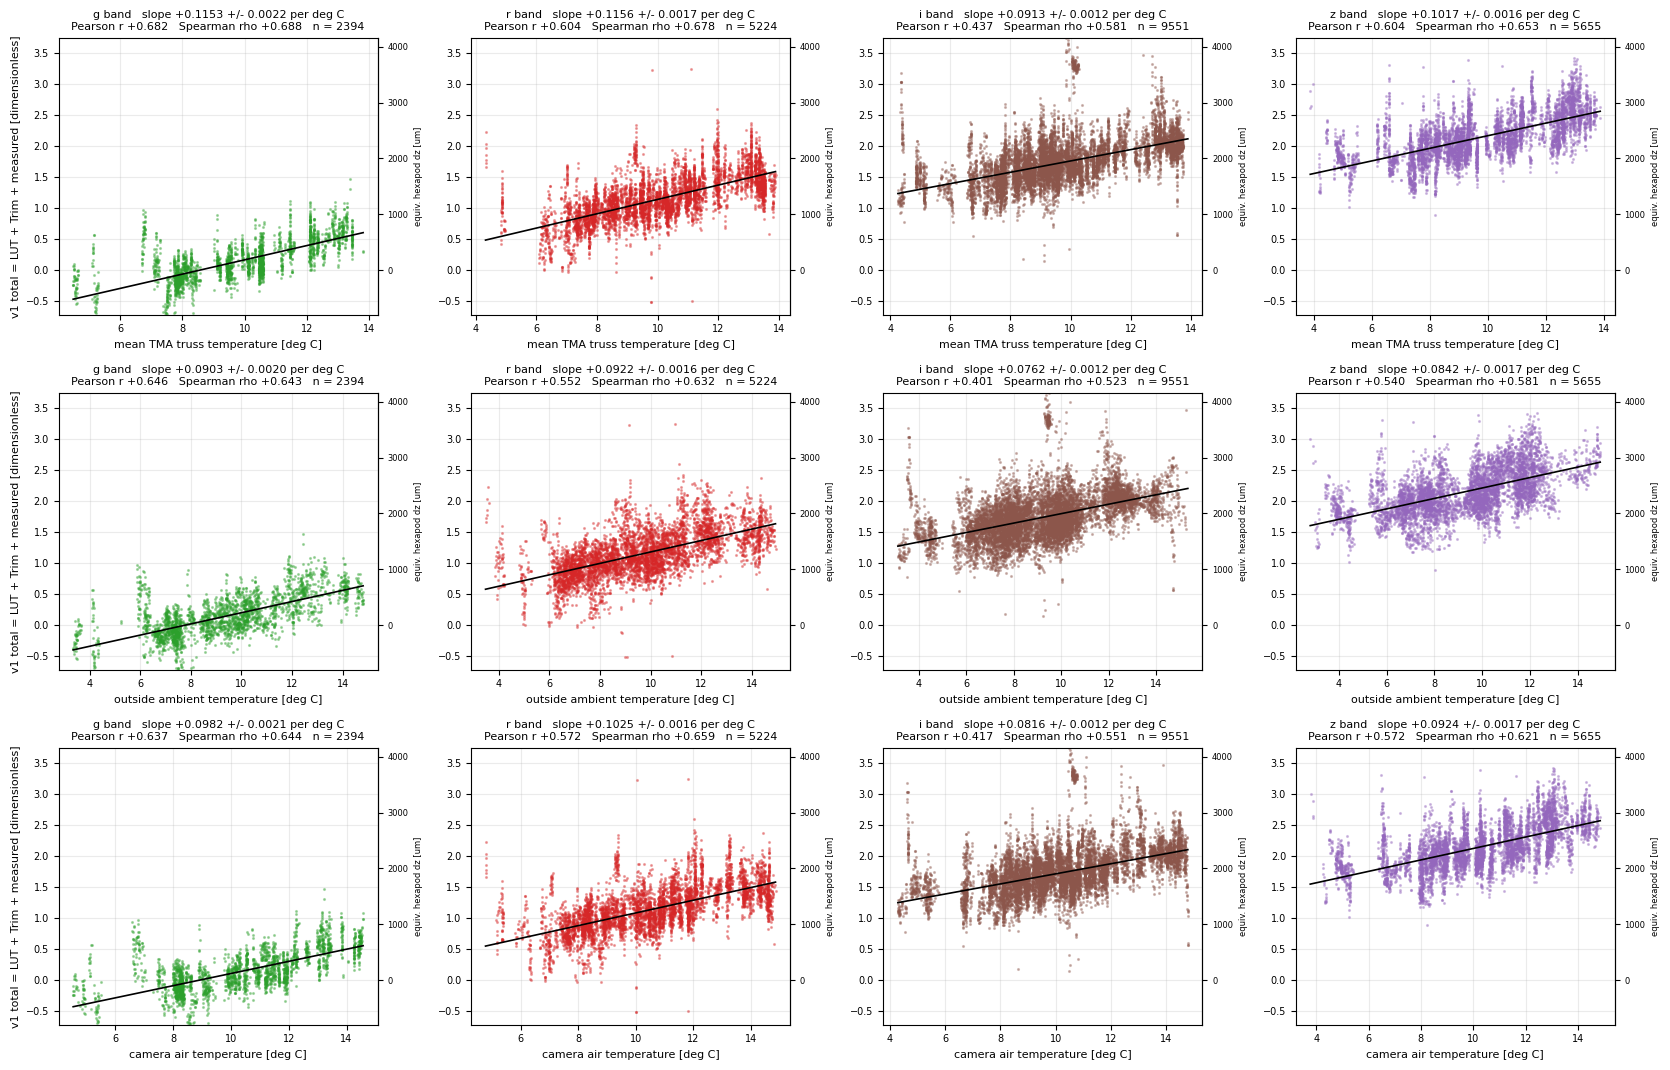

v1_total against temperature, by band:
temperature band    n   slope  slope_err  pearson_r  spearman_rho  resid_nmad
      truss    g 2394 +0.1153    +0.0022    +0.6820       +0.6875     +0.2152
      truss    r 5224 +0.1156    +0.0017    +0.6038       +0.6782     +0.2432
      truss    i 9551 +0.0913    +0.0012    +0.4375       +0.5813     +0.2414
      truss    z 5655 +0.1017    +0.0016    +0.6042       +0.6528     +0.2670
    ambient    g 2394 +0.0903    +0.0020    +0.6458       +0.6425     +0.2310
    ambient    r 5224 +0.0922    +0.0016    +0.5525       +0.6325     +0.2597
    ambient    i 9551 +0.0762    +0.0012    +0.4011       +0.5227     +0.2681
    ambient    z 5655 +0.0842    +0.0017    +0.5404       +0.5806     +0.2848
     camera    g 2394 +0.0982    +0.0021    +0.6371       +0.6437     +0.2344
     camera    r 5224 +0.1025    +0.0016    +0.5724       +0.6593     +0.2495
     camera    i 9551 +0.0816    +0.0012    +0.4167       +0.5513     +0.2576
     camera    z 5655 +0.

In [17]:
sum_total = scatter_page('v1_total',
                         'v1 total = LUT + Trim + measured [dimensionless]',
                         'corner_z4_vs_temperature_science_v1_total.png')
print('v1_total against temperature, by band:')
print(sum_total[['temperature', 'band', 'n', 'slope', 'slope_err', 'pearson_r',
                 'spearman_rho', 'resid_nmad']].to_string(
    index=False, float_format=lambda v: f'{v:+.4f}'))

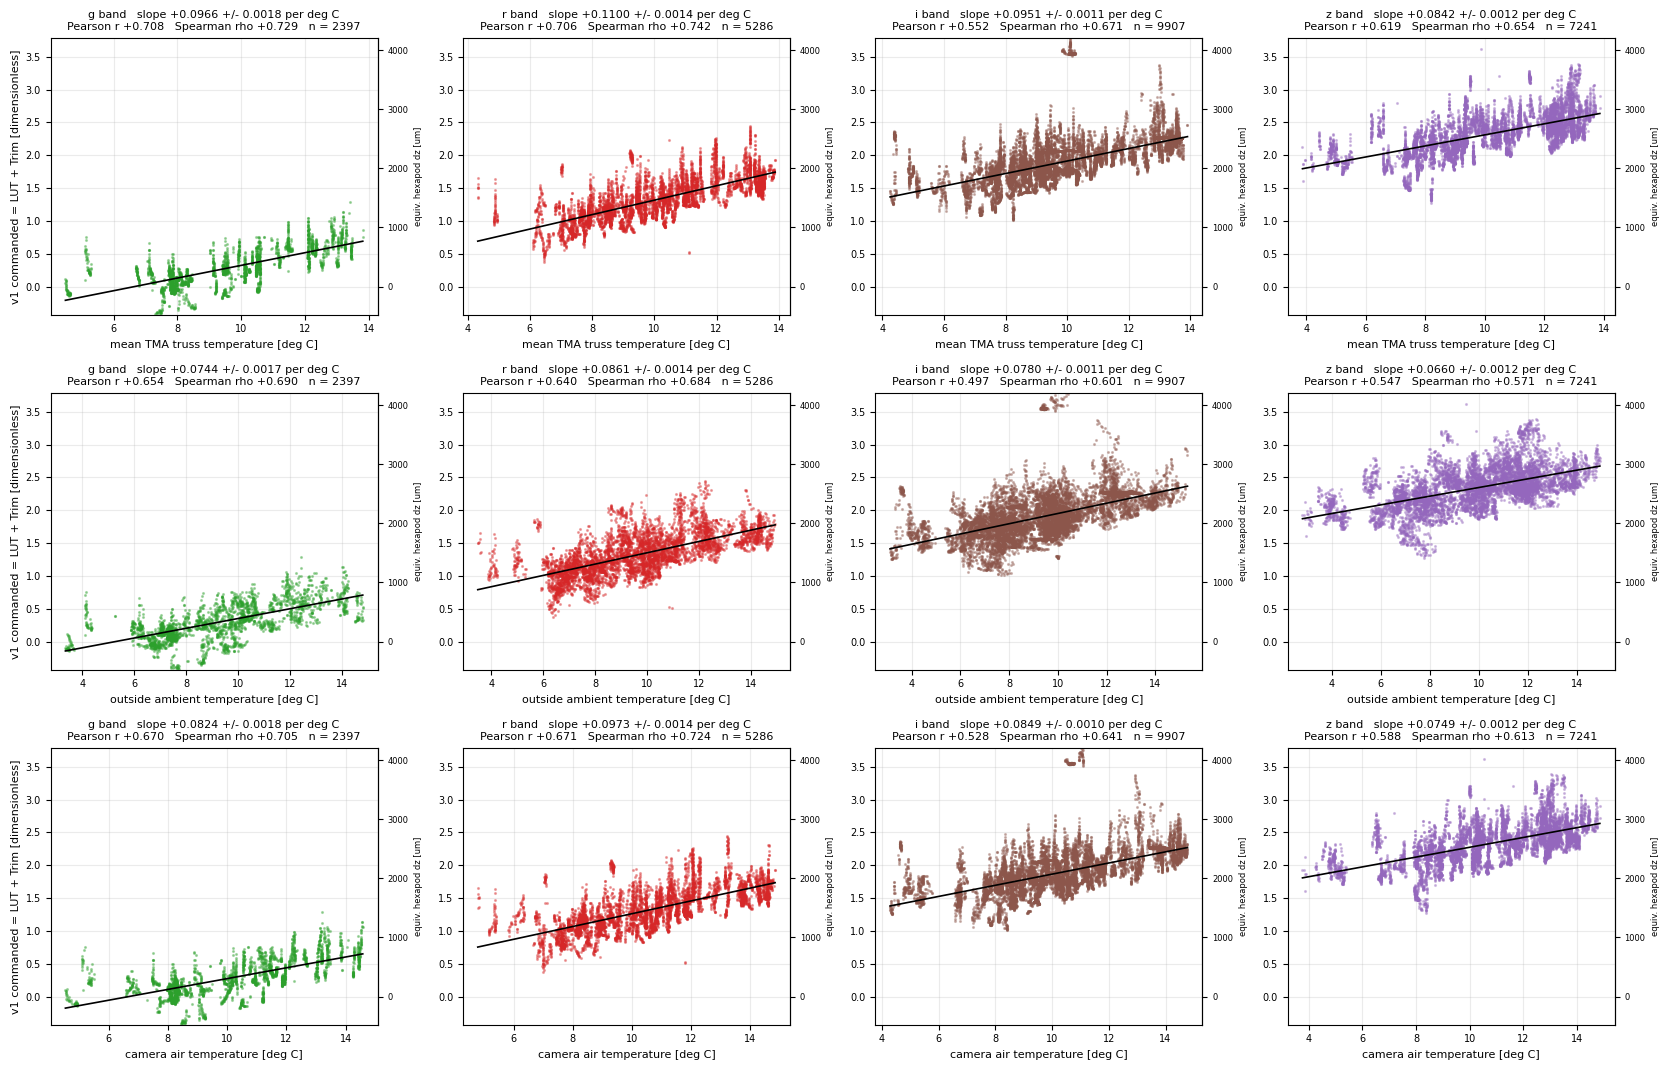

v1(LUT+Trim) against temperature, by band -- compare the truss rows against the FAM result of
+0.09634 per deg C for the lower Trim population in run_dz14_truss.py:
temperature band    n   slope  slope_err  pearson_r  spearman_rho  resid_nmad
      truss    g 2397 +0.0966    +0.0018    +0.7084       +0.7290     +0.1676
      truss    r 5286 +0.1100    +0.0014    +0.7062       +0.7420     +0.2052
      truss    i 9907 +0.0951    +0.0011    +0.5516       +0.6707     +0.2099
      truss    z 7241 +0.0842    +0.0012    +0.6188       +0.6544     +0.2250
    ambient    g 2397 +0.0744    +0.0017    +0.6545       +0.6899     +0.1891
    ambient    r 5286 +0.0861    +0.0014    +0.6397       +0.6839     +0.2236
    ambient    i 9907 +0.0780    +0.0011    +0.4969       +0.6008     +0.2330
    ambient    z 7241 +0.0660    +0.0012    +0.5467       +0.5713     +0.2395
     camera    g 2397 +0.0824    +0.0018    +0.6697       +0.7053     +0.1851
     camera    r 5286 +0.0973    +0.0014    +0.6705    

In [18]:
sum_cmd = scatter_page('v1_lut_trim',
                       'v1 commanded = LUT + Trim [dimensionless]',
                       'corner_z4_vs_temperature_science_v1_lut_trim.png')
print('v1(LUT+Trim) against temperature, by band -- compare the truss rows against the FAM '
      'result of\n+0.09634 per deg C for the lower Trim population in run_dz14_truss.py:')
print(sum_cmd[['temperature', 'band', 'n', 'slope', 'slope_err', 'pearson_r',
               'spearman_rho', 'resid_nmad']].to_string(
    index=False, float_format=lambda v: f'{v:+.4f}'))

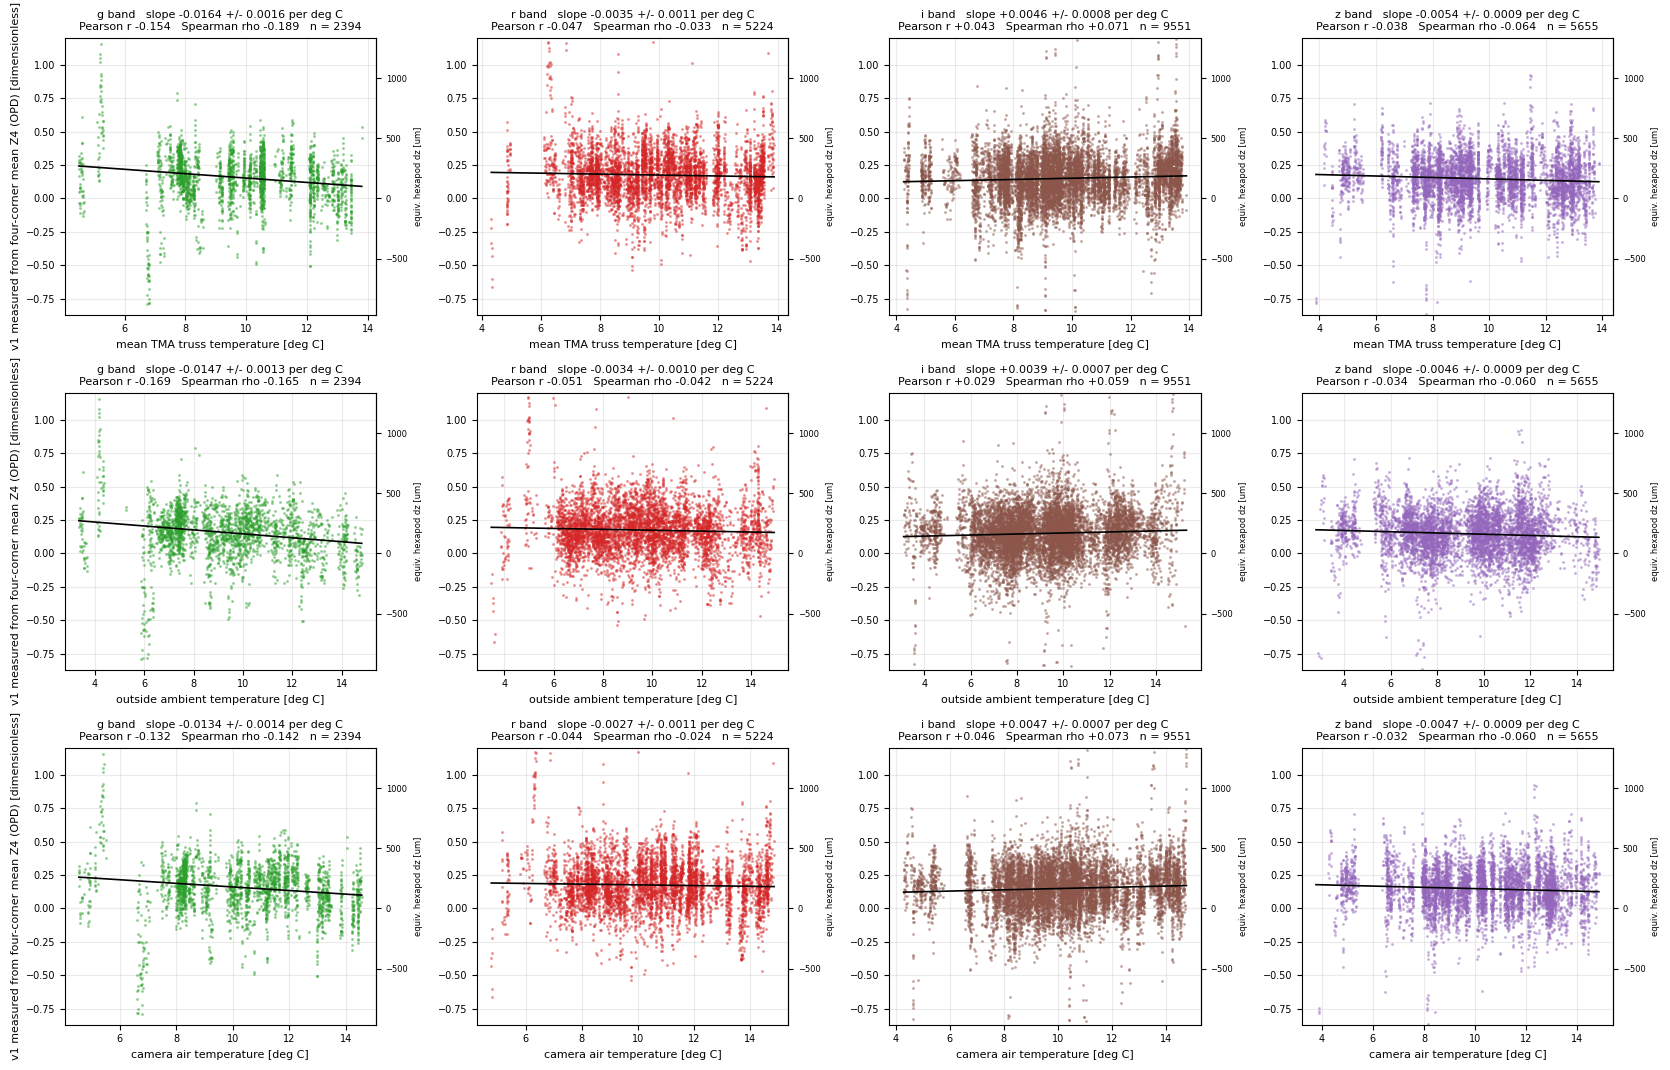

v1 from the four-corner mean Z4 (OPD) alone against temperature, by band:
temperature band    n   slope  slope_err  pearson_r  spearman_rho  resid_nmad
      truss    g 2394 -0.0164    +0.0016    -0.1542       -0.1890     +0.1500
      truss    r 5224 -0.0035    +0.0011    -0.0470       -0.0328     +0.1550
      truss    i 9551 +0.0046    +0.0008    +0.0435       +0.0709     +0.1541
      truss    z 5655 -0.0054    +0.0009    -0.0379       -0.0642     +0.1493
    ambient    g 2394 -0.0147    +0.0013    -0.1692       -0.1647     +0.1513
    ambient    r 5224 -0.0034    +0.0010    -0.0509       -0.0419     +0.1549
    ambient    i 9551 +0.0039    +0.0007    +0.0294       +0.0587     +0.1541
    ambient    z 5655 -0.0046    +0.0009    -0.0340       -0.0604     +0.1493
     camera    g 2394 -0.0134    +0.0014    -0.1323       -0.1423     +0.1506
     camera    r 5224 -0.0027    +0.0011    -0.0438       -0.0241     +0.1549
     camera    i 9551 +0.0047    +0.0007    +0.0457       +0.0730   

In [19]:
sum_meas = scatter_page('v1_meas',
                        'v1 measured from four-corner mean Z4 (OPD) [dimensionless]',
                        'corner_z4_vs_temperature_science_v1_meas.png')
print('v1 from the four-corner mean Z4 (OPD) alone against temperature, by band:')
print(sum_meas[['temperature', 'band', 'n', 'slope', 'slope_err', 'pearson_r',
                'spearman_rho', 'resid_nmad']].to_string(
    index=False, float_format=lambda v: f'{v:+.4f}'))

In [20]:
summary = pd.concat([sum_total.assign(quantity='v1_total'),
                     sum_cmd.assign(quantity='v1_lut_trim'),
                     sum_meas.assign(quantity='v1_meas')], ignore_index=True)
pooled = []
for q, col in (('v1_total', 'v1_total'), ('v1_lut_trim', 'v1_lut_trim'),
               ('v1_meas', 'v1_meas')):
    for t in ('truss', 'ambient', 'camera'):
        r = huber_fit(df[t], df[col])
        if r:
            pooled.append(dict(quantity=q, temperature=t, band='all', **r))
pooled = pd.DataFrame(pooled)
summary = pd.concat([summary, pooled], ignore_index=True)
sp = OUT / 'corner_z4_vs_temperature_science_summary.parquet'
summary.to_parquet(sp)
print('all bands pooled:')
print(pooled[['quantity', 'temperature', 'n', 'slope', 'slope_err', 'pearson_r',
              'spearman_rho', 'resid_nmad']].to_string(
    index=False, float_format=lambda v: f'{v:+.4f}'))
print(f'\nsummary written to {sp}')

all bands pooled:
   quantity temperature     n   slope  slope_err  pearson_r  spearman_rho  resid_nmad
   v1_total       truss 22824 +0.0924    +0.0019    +0.2886       +0.3210     +0.5660
   v1_total     ambient 22824 +0.0708    +0.0017    +0.2480       +0.2887     +0.5701
   v1_total      camera 22824 +0.0792    +0.0018    +0.2635       +0.3033     +0.5713
v1_lut_trim       truss 24831 +0.1052    +0.0016    +0.3407       +0.3961     +0.5171
v1_lut_trim     ambient 24831 +0.0820    +0.0015    +0.2963       +0.3558     +0.5259
v1_lut_trim      camera 24831 +0.0923    +0.0016    +0.3175       +0.3760     +0.5188
    v1_meas       truss 22824 -0.0015    +0.0005    -0.0069       -0.0082     +0.1540
    v1_meas     ambient 22824 -0.0017    +0.0005    -0.0158       -0.0162     +0.1540
    v1_meas      camera 22824 -0.0009    +0.0005    -0.0023       -0.0028     +0.1544

summary written to /sdf/home/r/roodman/notebooks/rubin-work/aos/output/notebooks/correlations/corner_z4_vs_temperature_sc

In [21]:
# Equivalent focus sensitivity, for comparison with the thermal cross-check in
# run_dz14_truss.py: 106.9 um of hexapod dz per deg C measured, against 94 um per deg C for a
# 7835 mm steel truss at 12 ppm per deg C.
print(f'{"quantity":14s} {"slope [1/degC]":>16s} {"um hex dz per degC":>20s} '
      f'{"um wavefront per degC":>22s}')
for _, r in pooled[pooled.temperature == 'truss'].iterrows():
    um_per_c = r.slope / V1_PER_UM_DZ
    wf_per_c = um_per_c / abs(DZ_TO_UM)
    print(f'{r.quantity:14s} {r.slope:+16.5f} {um_per_c:+20.1f} {wf_per_c:+22.4f}')
print(f'\nsteel truss reference: {7835.0*1e3*12e-6:.0f} um per deg C '
      f'(7835 mm at 12 ppm per deg C)')

quantity         slope [1/degC]   um hex dz per degC  um wavefront per degC
v1_total               +0.09242               +102.6                +0.0924
v1_lut_trim            +0.10524               +116.8                +0.1052
v1_meas                -0.00150                 -1.7                -0.0015

steel truss reference: 94 um per deg C (7835 mm at 12 ppm per deg C)


<a id="findings"></a>
## 9. Findings

Filled in from the executed output below.

In [22]:
lines = []
n_tot = int(np.isfinite(df.v1_total).sum())
lines.append(f'Sample: n = {len(df)} science visits in g/r/i/z over day_obs {DAY_OBS_MIN} to '
             f'{DAY_OBS_MAX} ({df.day_obs.nunique()} nights), of which n = {n_tot} carry a '
             f'finite v1_total.')
for q in ('v1_total', 'v1_lut_trim', 'v1_meas'):
    r = pooled[(pooled.quantity == q) & (pooled.temperature == 'truss')]
    if len(r):
        r = r.iloc[0]
        lines.append(f'{q} against mean TMA truss temperature: Huber slope '
                     f'{r.slope:+.5f} +/- {r.slope_err:.5f} per deg C (dimensionless v-mode 1 '
                     f'amplitude per deg C), Pearson r = {r.pearson_r:+.3f}, Spearman rho = '
                     f'{r.spearman_rho:+.3f}, n = {int(r.n)}, residual nMAD '
                     f'{r.resid_nmad:.4f} (dimensionless).')
for t, nm in (('ambient', 'outside ambient temperature'), ('camera', CAMERA_LABEL)):
    r = pooled[(pooled.quantity == 'v1_total') & (pooled.temperature == t)]
    if len(r):
        r = r.iloc[0]
        lines.append(f'v1_total against {nm}: Huber slope {r.slope:+.5f} +/- '
                     f'{r.slope_err:.5f} per deg C, Pearson r = {r.pearson_r:+.3f}, '
                     f'Spearman rho = {r.spearman_rho:+.3f}, n = {int(r.n)}.')
lines.append(f'The measured wavefront term is small next to the commanded one: nMAD '
             f'{nmad((BEST_SIGN*df.v1_meas).to_numpy()):.4f} against '
             f'{nmad(df.v1_lut_trim.to_numpy()):.4f} for LUT+Trim (both dimensionless), so '
             f'v1_total is dominated by the commanded state.')
print('\n\n'.join(lines))

Sample: n = 27671 science visits in g/r/i/z over day_obs 20260419 to 20260713 (52 nights), of which n = 25430 carry a finite v1_total.

v1_total against mean TMA truss temperature: Huber slope +0.09242 +/- 0.00186 per deg C (dimensionless v-mode 1 amplitude per deg C), Pearson r = +0.289, Spearman rho = +0.321, n = 22824, residual nMAD 0.5660 (dimensionless).

v1_lut_trim against mean TMA truss temperature: Huber slope +0.10524 +/- 0.00163 per deg C (dimensionless v-mode 1 amplitude per deg C), Pearson r = +0.341, Spearman rho = +0.396, n = 24831, residual nMAD 0.5171 (dimensionless).

v1_meas against mean TMA truss temperature: Huber slope -0.00150 +/- 0.00050 per deg C (dimensionless v-mode 1 amplitude per deg C), Pearson r = -0.007, Spearman rho = -0.008, n = 22824, residual nMAD 0.1540 (dimensionless).

v1_total against outside ambient temperature: Huber slope +0.07083 +/- 0.00174 per deg C, Pearson r = +0.248, Spearman rho = +0.289, n = 22824.

v1_total against camera air temperat